# Tutorial-1

We will go through all the steps to make a simple BCI classification task, downloading a dataset and using a standard classifier. We choose the dataset 2a from BCI Competition IV, a motor imagery task. We will use a CSP to enhance the signal-to-noise ratio of the EEG epochs and a LDA to classify these signals.

In [2]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.pipeline import make_pipeline

import moabb
from moabb.datasets import BNCI2014_001
from moabb.evaluations import WithinSessionEvaluation
from moabb.paradigms import LeftRightImagery

moabb.set_log_level("info")
warnings.filterwarnings("ignore")

## Instantiating Dataset

The first thing to do is to instantiate the dataset that we want to analyze. MOABB has a list of many different datasets, each one containing all the necessary information for describing them, such as the number of subjects, size of trials, names of classes, etc.

The dataset class has methods for:

    1. downloading its files from some online source (e.g. Zenodo)

    2. importing the data from the files in whatever extension they might be (like .mat, .gdf, etc.) and instantiate a Raw object from the MNE package


In [3]:
dataset = BNCI2014_001()
dataset.subject_list = [1,2,3]


## Accessing EEG Recording 

EEG refers to electroencephalogram, it is a non-invasive medical test that measures and records the electrical activity of the brain. 

we may access the EEG recording from a given session and a given run

In [4]:
sessions = dataset.get_data(subjects=[1])

2026-07-15 14:38:27,800 INFO MainThread moabb.datasets.download MNE_DATA is not already configured. It will be set to default location in the home directory - /Users/sheehanmathur/mne_data
All datasets will be downloaded to this location, if anything is already downloaded, please move manually to this location
100%|█████████████████████████████████████| 42.8M/42.8M [00:00<00:00, 78.0GB/s]
SHA256 hash of downloaded file: 054f02e70cf9c4ada1517e9b9864f45407939c1062c6793516585c6f511d0325
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
100%|█████████████████████████████████████| 43.8M/43.8M [00:00<00:00, 63.3GB/s]
SHA256 hash of downloaded file: 53d415f39c3d7b0c88b894d7b08d99bcdfe855ede63831d3691af1a45607fb62
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


This returns a MNE Raw object that can be manipulated. This might be enough for some users, since the pre-processing and epoching steps can be easily done via MNE. However, to conduct an assessment of several classifiers on multiple subjects, MOABB ends up being a more appropriate option.

In [5]:
subject = 1
session_name = "0train"
run_name = "0"
raw = sessions[subject][session_name][run_name]

## Choosing a Paradigm

Once we have instantiated a dataset, we have to choose a paradigm. This object is responsible for filtering the data, epoching it, and extracting the labels for each epoch. Note that each dataset comes with the names of the paradigms to which it might be associated. It would not make sense to process a P300 dataset with a MI paradigm object.

In [6]:
print (dataset.paradigm)

imagery


In [8]:
paradigm = LeftRightImagery()
print (paradigm.datasets)

[<moabb.datasets.bnci.bnci_2014.BNCI2014_001 object at 0x3092dced0>, <moabb.datasets.bnci.bnci_2014.BNCI2014_004 object at 0x32724c290>, <moabb.datasets.beetl.Beetl2021_A object at 0x308dc7e90>, <moabb.datasets.beetl.Beetl2021_B object at 0x308155d50>, <moabb.datasets.brandl2020.Brandl2020 object at 0x32727e490>, <moabb.datasets.chang2025.Chang2025 object at 0x327257150>, <moabb.datasets.gigadb.Cho2017 object at 0x113a84e10>, <moabb.datasets.dreyer2023.Dreyer2023 object at 0x32725c710>, <moabb.datasets.dreyer2023.Dreyer2023A object at 0x327230210>, <moabb.datasets.dreyer2023.Dreyer2023B object at 0x17ec2f750>, <moabb.datasets.dreyer2023.Dreyer2023C object at 0x3272301d0>, <moabb.datasets.forenzo2023.Forenzo2023 object at 0x3092f0490>, <moabb.datasets.mpi_mi.GrosseWentrup2009 object at 0x3092e35d0>, <moabb.datasets.guttmann_flury2025.GuttmannFlury2025_ME object at 0x3272730d0>, <moabb.datasets.guttmann_flury2025.GuttmannFlury2025_MI object at 0x3092b0d90>, <moabb.datasets.hefmi_ich2025.

The data from a list of subjects could be preprocessed and return as a 3D numpy array X, follow a scikit-like format with the associated labels. The meta object contains all information regarding the subject, the session and the run associated to each trial.

In [9]:
X, labels, meta = paradigm.get_data(dataset=dataset, subjects=[1])

## Create Pipeline

Our goal is to evaluate the performance of a given classification pipeline (or several of them) when it is applied to the epochs from the previously chosen dataset. We will consider a very simple classification pipeline in which the dimension of the epochs are reduced via a CSP step and then classified via a linear discriminant analysis.



In [13]:
pipeline = make_pipeline(CSP(n_components=8), LDA())

## Evaluation

To evaluate the score of this pipeline, we use the evaluation class. When instantiating it, we say which paradigm we want to consider, a list with the datasets to analyze, and whether the scores should be recalculated each time we run the evaluation or if MOABB should create a cache file.

Note that there are different ways of evaluating a classifier. WithinSessionEvaluation, which consists of doing a cross-validation procedure where the training and testing partitions are from the same recording session of the dataset. We could have used CrossSessionEvaluation, which takes all but one session as training partition and the remaining one as testing partition.

In [14]:
evaluation = WithinSessionEvaluation(
    paradigm=paradigm, datasets=[dataset], overwrite=True, hdf5_path=None
)
results = evaluation.process({"csp+lda": pipeline})

100%|██████████████████████████████████████| 43.1M/43.1M [00:00<00:00, 104GB/s]
SHA256 hash of downloaded file: 5ddd5cb520b1692c3ba1363f48d98f58f0e46f3699ee50d749947950fc39db27
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
100%|██████████████████████████████████████| 44.2M/44.2M [00:00<00:00, 105GB/s]
SHA256 hash of downloaded file: d63c454005d3a9b41d8440629482e855afc823339bdd0b5721842a7ee9cc7b12
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
100%|█████████████████████████████████████| 44.1M/44.1M [00:00<00:00, 28.0GB/s]
SHA256 hash of downloaded file: 7e731ee8b681d5da6ecb11ae1d4e64b1653c7f15aad5d6b7620b25ce53141e80
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
100%|████████████████████████████████

In [15]:
results.to_csv("./results_part2-1.csv")
results = pd.read_csv("./results_part2-1.csv")

## Plotting Results

We create a figure with the seaborn package comparing the classification score for each subject on each session. Note that the ‘subject’ field from the results is given in terms of integers, but seaborn accepts only strings for its labeling. This is why we create the field ‘subj’.

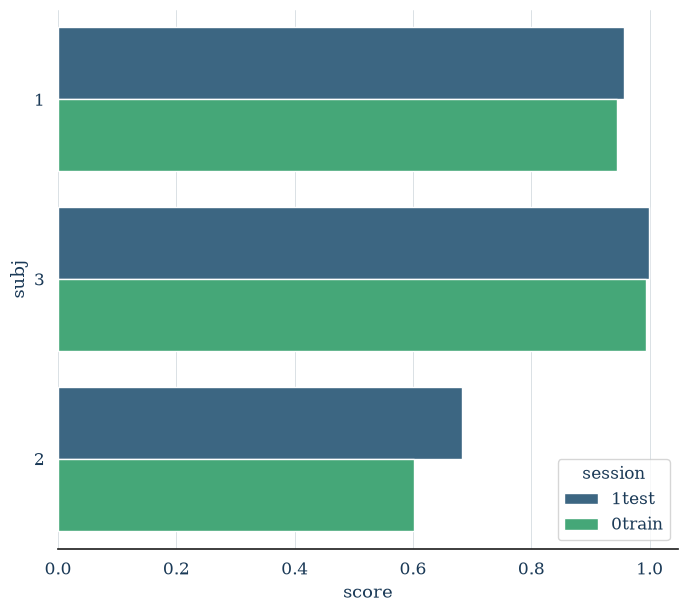

In [17]:
fig, ax = plt.subplots(figsize=(8,7))
results["subj"] = results["subject"].apply(str)
sns.barplot(
    x="score", y="subj", hue="session", data=results, orient="h", palette="viridis", ax=ax
)
plt.show()